# Introducción

Una vez finalizado el proceso de limpieza, transformación y reducción de dimensionalidad de los datos, el siguiente paso consiste en construir y evaluar modelos de aprendizaje automático capaces de predecir si un video presentará **engagement**.

El objetivo principal de esta etapa es identificar el modelo que mejor logre detectar videos con alto nivel de interacción por parte de los usuarios. Dado el contexto del problema, se prioriza la **capacidad de identificar correctamente los casos positivos**, es decir, minimizar los falsos negativos. Por esta razón, el **recall** será la métrica principal utilizada durante la evaluación de los modelos.

Para analizar el impacto de las diferentes estrategias de preparación de datos, los modelos se entrenarán y evaluarán utilizando tres conjuntos de variables distintos generados durante el proceso de preprocesamiento:

- **Dataset completo:** contiene todas las variables predictoras disponibles tras eliminar variables con riesgo de *data leakage*.
- **Dataset reducido por correlación (incompleto):** incluye únicamente las variables seleccionadas tras el análisis de correlación estadística.
- **Dataset transformado mediante PCA:** utiliza componentes principales obtenidos a partir de un análisis de reducción de dimensionalidad.

Sobre estos tres conjuntos de datos se entrenarán y compararán distintos modelos de clasificación, abarcando desde enfoques lineales hasta métodos basados en árboles y *boosting*. Posteriormente, se analizará su desempeño mediante diversas métricas de evaluación y curvas de diagnóstico, con el objetivo de identificar el modelo más adecuado para el problema.

Finalmente, una vez seleccionados los modelos con mejor desempeño, se ajustará el umbral de decisión para asegurar un nivel de **recall adecuado**, manteniendo al mismo tiempo un equilibrio razonable con la precisión del modelo.

### **Modelos Evaluados**
- *Regresión Logistica*
- *Arboles de Decisión*
- *Random Forests*
- *XGBoost*

## Método de Evaluación

Para evaluar el desempeño de los modelos se utilizaron diferentes métricas y herramientas de diagnóstico con el objetivo de analizar su capacidad de discriminación entre videos con **alto** y **bajo engagement**.

En primer lugar, se utilizó la métrica **ROC AUC**, que permite medir la capacidad del modelo para distinguir entre ambas clases independientemente del umbral de clasificación. Esta métrica se empleó durante el proceso de **ajuste de hiperparámetros mediante GridSearchCV**, permitiendo seleccionar la configuración que maximiza la capacidad discriminativa del modelo.

Posteriormente, el desempeño de cada modelo se analizó utilizando múltiples métricas de clasificación, incluyendo **recall, precision y accuracy**, así como herramientas visuales como la **curva ROC**, la **curva Precision–Recall** y la **matriz de confusión**.

Dado que el objetivo del proyecto es **minimizar los falsos negativos**, se dio especial prioridad al **recall**, ya que esta métrica mide la proporción de casos positivos correctamente identificados por el modelo. En este contexto, resulta preferible clasificar algunos casos negativos como positivos (falsos positivos) antes que omitir contenidos con alto engagement.

Finalmente, se realizó un **ajuste del umbral de decisión** para cada modelo con el objetivo de alcanzar un **recall mínimo de 0.8**, seleccionando posteriormente el modelo que logra mantener este nivel de recall con la mayor precisión posible.

## **Librerias**

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#modelos de machine learning
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xg

#Ajuste de los modelos 
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold

#Metodos de evaluación
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score


from sklearn.preprocessing import StandardScaler




## **Conjuntos de datos** (***Datasets***)

In [2]:
#Conjunto completo
X_train = pd.read_pickle('../data/processed/X_train.pkl')
X_test = pd.read_pickle('../data/processed/X_test.pkl')

#Conjunto reducido por analisis estructural
X_train_reduce = pd.read_pickle('../data/processed/X_train_reduce.pkl')
X_test_reduce = pd.read_pickle('../data/processed/X_test_reduce.pkl')


#Conjunto reducido por analisis de componentes
X_train_pca = pd.read_pickle('../data/processed/X_train_pca.pkl')
X_test_pca = pd.read_pickle('../data/processed/X_test_pca.pkl')

#Variable objetivo
Y_train = pd.read_pickle('../data/processed/y_train.pkl')
Y_test = pd.read_pickle('../data/processed/y_test.pkl')


## **Funciones**

In [3]:
def Standard_scale(train_set, test_set):
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_set)
    test_scaled = scaler.transform(test_set)

    return train_scaled, test_scaled

def evaluation(Y_test, Y_predicted, Y_predicted_prob):
    fpr, tpr, thresholds_roc = roc_curve(Y_test, Y_predicted_prob)
    precision, recall, thresholds_PrecisionRecall = precision_recall_curve(Y_test, Y_predicted_prob)
    matrix = confusion_matrix(Y_test, Y_predicted)

    # Generate classification report as DataFrame for later comparison
    class_report_dict = classification_report(Y_test, Y_predicted, output_dict=True)
    accuracy = accuracy_score(Y_test, Y_predicted)
    auc_score = auc(fpr, tpr)
    class_report_df = pd.DataFrame(
        {
            'value': [
                class_report_dict['1']['precision'],
                class_report_dict['1']['recall'],
                accuracy,
                auc_score,
            ]
        },
        index=['precision', 'recall', 'accuracy', 'auc'],
    ).round(4)

    fig, axs = plt.subplots(2, 3, figsize=(10, 6))

    sns.color_palette('muted')
    # ROC curve
    sns.lineplot(x=fpr, y=tpr, ax=axs[0, 0], label=f'ROC curve (AUC = {auc(fpr, tpr):.2f})')
    sns.lineplot(x=[0, 1], y=[0, 1], ax=axs[0, 0], linestyle='--')
    axs[0, 0].set_xlim([0.0, 1.0])
    axs[0, 0].set_ylim([0.0, 1.05])
    axs[0, 0].set_xlabel('False Positive Rate')
    axs[0, 0].set_ylabel('True Positive Rate')
    axs[0, 0].set_title('ROC Curve')
    axs[0, 0].legend(loc='lower right')

    # Precision-Recall curve
    sns.lineplot(x=precision, y=recall, ax=axs[0, 1], label='PRECISION-RECALL curve')
    sns.lineplot(x=[0, 1], y=[0, 1], ax=axs[0, 1],  linestyle='--')
    axs[0, 1].set_xlim([0.0, 1.0])
    axs[0, 1].set_ylim([0.0, 1.05])
    axs[0, 1].set_xlabel('Precision')
    axs[0, 1].set_ylabel('Recall')
    axs[0, 1].set_title('Precision-Recall Curve')
    axs[0, 1].legend(loc='lower right')

    # Confusion Matrix
    sns.heatmap(matrix, annot=True, cmap='Blues', fmt='d',
                xticklabels=['Predicho 0', 'Predicho 1'],
                yticklabels=['Real 0', 'Real 1'], ax=axs[0, 2])
    axs[0, 2].set_xlabel('Etiqueta Predicha')
    axs[0, 2].set_ylabel('Etiqueta Real')
    axs[0, 2].set_title('Matriz de confusión')

    # Thresholds vs Recall
    sns.lineplot(x=thresholds_PrecisionRecall, y=recall[1:], ax=axs[1, 0])
    axs[1, 0].set_xlabel('Threshold')
    axs[1, 0].set_ylabel('Recall')
    axs[1, 0].set_title('Threshold vs Recall')

    # Thresholds vs Precision
    sns.lineplot(x=thresholds_PrecisionRecall, y=precision[1:], ax=axs[1, 1])
    axs[1, 1].set_xlabel('Threshold')
    axs[1, 1].set_ylabel('Precision')
    axs[1, 1].set_title('Threshold vs Precision')

    # Empty axis for alignment
    axs[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

    return class_report_df

def grid_search_model(model, param_grid, X_train, y_train):

    pipe = Pipeline([
        ("model", model)
    ])

    grid = GridSearchCV(
        pipe,
        param_grid,
        scoring="roc_auc",
        cv = StratifiedKFold(n_splits=5),
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    return grid


## **Ajuste de modelos**

Con el objetivo de identificar el modelo más adecuado para predecir **alto engagement**, se entrenaron distintos algoritmos de clasificación utilizando los conjuntos de datos generados durante la etapa de preprocesamiento.

El ajuste de los modelos se realizó mediante **GridSearchCV** con validación cruzada de 5 particiones sobre el conjunto de entrenamiento. Durante este proceso, la métrica utilizada para optimizar los hiperparámetros fue **ROC AUC**, ya que permite evaluar la capacidad del modelo para discriminar entre las dos clases independientemente del umbral de clasificación.

Se evaluaron cuatro algoritmos de clasificación:

- Logistic Regression  
- Decision Tree  
- Random Forest  
- XGBoost  

Cada uno de estos modelos fue entrenado utilizando **tres representaciones distintas de los datos**:

- Dataset completo  
- Dataset reducido por correlación  
- Dataset transformado mediante PCA  

En el caso de **Logistic Regression**, se aplicó **StandardScaler** para estandarizar las variables, dado que los modelos lineales son sensibles a la escala de los datos. Los modelos basados en árboles no requieren este tipo de transformación.

In [4]:
#Regresión logistica
X_train_scaled, X_test_scaled = Standard_scale(X_train, X_test)
X_train_reduced_scaled,  X_test_reduced_scaled = Standard_scale(X_train_reduce, X_test_reduce) 


param_grid_log = {'model__C': [0.001, 0.01, 0.1, 1]}
model_logistic_completo = grid_search_model(LogisticRegression(random_state= 0, class_weight= 'balanced', solver= 'liblinear'), 
                                            param_grid= param_grid_log,
                                            X_train= X_train_scaled, 
                                            y_train= Y_train)

model_logistic_incompleto = grid_search_model(LogisticRegression(random_state= 0, class_weight= 'balanced', solver= 'liblinear'), 
                                            param_grid= param_grid_log,
                                            X_train= X_train_reduced_scaled, 
                                            y_train= Y_train)

model_logistic_pca = grid_search_model(LogisticRegression(random_state= 0, class_weight= 'balanced', solver= 'liblinear'), 
                                            param_grid= param_grid_log,
                                            X_train= X_train_pca, 
                                            y_train= Y_train)


#Arboles de decisión
param_grid_dt = {'model__max_depth': [5, 10, 15, 20]}

model_tree_completo = grid_search_model(DecisionTreeClassifier(random_state=0, class_weight= 'balanced'), 
                                        param_grid= param_grid_dt,
                                        X_train= X_train,
                                        y_train= Y_train)

model_tree_incompleto = grid_search_model(DecisionTreeClassifier(random_state=0, class_weight= 'balanced'), 
                                        param_grid= param_grid_dt,
                                        X_train= X_train_reduce,
                                        y_train= Y_train)

model_tree_pca = grid_search_model(DecisionTreeClassifier(random_state=0, class_weight= 'balanced'), 
                                        param_grid= param_grid_dt,
                                        X_train= X_train_pca,
                                        y_train= Y_train)

#Random forests
param_grid_rf = {'model__max_depth': [5, 10], 'model__n_estimators': [100, 200, 250]}

model_rforest_completo = grid_search_model(RandomForestClassifier(max_features='sqrt', random_state=0, class_weight= 'balanced'), 
                                           param_grid= param_grid_rf,
                                           X_train= X_train,
                                           y_train= Y_train)

                                                

model_rforest_incompleto = grid_search_model(RandomForestClassifier(max_features='sqrt', random_state=0, class_weight= 'balanced'), 
                                           param_grid= param_grid_rf,
                                           X_train= X_train_reduce,
                                           y_train= Y_train)

model_rforest_pca = grid_search_model(RandomForestClassifier(max_features='sqrt', random_state=0, class_weight= 'balanced'), 
                                           param_grid= param_grid_rf,
                                           X_train= X_train_pca,
                                           y_train= Y_train)

#XGboost
param_grid_xgb = {'model__max_depth': [5, 10], 'model__n_estimators': [100, 200, 250], 'model__learning_rate' : [0.001, 0.01, 0.1]}

model_XGB_completo = grid_search_model(xg.XGBClassifier(subsample = 1, colsample_bytree = 1), 
                                       param_grid= param_grid_xgb,
                                       X_train= X_train,
                                       y_train= Y_train)

model_XGB_incompleto = grid_search_model(xg.XGBClassifier(subsample = 1, colsample_bytree = 1), 
                                       param_grid= param_grid_xgb,
                                       X_train= X_train_reduce,
                                       y_train= Y_train)

model_XGB_pca = grid_search_model(xg.XGBClassifier(subsample = 1, colsample_bytree = 1), 
                                       param_grid= param_grid_xgb,
                                       X_train= X_train_pca.to_numpy(),
                                       y_train= Y_train)


## **Evaluación del Ajuste de los Modelos**

Antes de evaluar el desempeño de los modelos, se analizó su **capacidad de generalización** comparando el desempeño en el conjunto de entrenamiento y en el conjunto de prueba mediante la métrica **ROC AUC**. Para ello se calculó el **AUC gap**, definido como la diferencia entre el AUC en entrenamiento y en prueba.

Los modelos de **Logistic Regression** presentan un gap prácticamente nulo, lo que indica una excelente capacidad de generalización. Los **Decision Tree** muestran una ligera diferencia entre entrenamiento y prueba (≈0.02), sugiriendo un leve sobreajuste, aunque dentro de un rango aceptable.

Por su parte, **Random Forest** presenta el mayor gap (≈0.11–0.12), lo que indica una mayor tendencia al sobreajuste debido a su alta capacidad de ajuste a los datos de entrenamiento. Finalmente, **XGBoost** también muestra cierta diferencia entre entrenamiento y prueba (≈0.08–0.09), aunque menor que la observada en Random Forest.

En general, todos los modelos mantienen un desempeño competitivo en el conjunto de prueba, por lo que se procede a evaluar su rendimiento en mayor detalle en la siguiente sección.

In [5]:
# AUC Train/Test para todos los modelos

models_auc = [
    ('Logistic Regression', 'Completo', model_logistic_completo, X_train_scaled, X_test_scaled),
    ('Logistic Regression', 'Incompleto', model_logistic_incompleto, X_train_reduced_scaled, X_test_reduced_scaled),
    ('Logistic Regression', 'PCA', model_logistic_pca, X_train_pca, X_test_pca),

    ('Decision Tree', 'Completo', model_tree_completo, X_train, X_test),
    ('Decision Tree', 'Concompleto', model_tree_incompleto, X_train_reduce, X_test_reduce),
    ('Decision Tree', 'PCA', model_tree_pca, X_train_pca, X_test_pca),

    ('Random Forest', 'Completo', model_rforest_completo, X_train, X_test),
    ('Random Forest', 'Incompleto', model_rforest_incompleto, X_train_reduce, X_test_reduce),
    ('Random Forest', 'PCA', model_rforest_pca, X_train_pca, X_test_pca),

    ('XGBoost', 'Completo', model_XGB_completo, X_train, X_test),
    ('XGBoost', 'Incompleto', model_XGB_incompleto, X_train_reduce, X_test_reduce),
    ('XGBoost', 'PCA', model_XGB_pca, X_train_pca.to_numpy(), X_test_pca.to_numpy()),
]

auc_rows = []
for model_name, dataset_name, model_obj, X_tr, X_te in models_auc:
    y_tr_prob = model_obj.predict_proba(X_tr)[:, 1]
    y_te_prob = model_obj.predict_proba(X_te)[:, 1]
    auc_tr = roc_auc_score(Y_train, y_tr_prob)
    auc_te = roc_auc_score(Y_test, y_te_prob)
    auc_rows.append({
        'Model': model_name,
        'Dataset': dataset_name,
        'AUC_train': auc_tr,
        'AUC_test': auc_te,
        'AUC_gap': auc_tr - auc_te,
    })

df_auc_summary = pd.DataFrame(auc_rows).round(4)
print('AUC summary (train/test):')

df_auc_summary


AUC summary (train/test):


,Model,Dataset,AUC_train,AUC_test,AUC_gap
0,Logistic Regression,Completo,0.8074,0.8070,0.0004
1,Logistic Regression,Incompleto,0.7944,0.8012,-0.0068
2,Logistic Regression,PCA,0.7996,0.8115,-0.0119
3,Decision Tree,Completo,0.8368,0.8106,0.0263
4,Decision Tree,Concompleto,0.8311,0.8088,0.0223
5,Decision Tree,PCA,0.8254,0.8083,0.0171
6,Random Forest,Completo,0.9700,0.8517,0.1183
7,Random Forest,Incompleto,0.9640,0.8422,0.1218
8,Random Forest,PCA,0.9678,0.8528,0.1150
9,XGBoost,Completo,0.9476,0.8566,0.0910


## **Evaluación**

### ***Regresión logistica***

Se entrenaron tres versiones del modelo de **Logistic Regression**, cada una utilizando una representación distinta de los datos: dataset completo, dataset reducido por correlación y dataset transformado mediante PCA. El objetivo fue analizar cómo las diferentes estrategias de preparación de variables afectan el desempeño del modelo.

Los resultados obtenidos muestran que las tres versiones del modelo presentan un desempeño similar. Sin embargo, el modelo entrenado sobre el **dataset transformado mediante PCA** obtuvo el mejor valor de **AUC (0.81)**, además del mayor **recall (0.75)** entre las tres configuraciones evaluadas. Dado que el objetivo del proyecto es priorizar la correcta identificación de los casos de alto engagement, el recall resulta una métrica especialmente relevante en esta etapa del análisis.

Aunque el modelo entrenado con el dataset completo presenta una precisión ligeramente superior, la diferencia es marginal frente a la mejora observada en recall en el modelo basado en PCA.

Por esta razón, el **modelo de Logistic Regression entrenado sobre el dataset PCA** fue seleccionado como la mejor versión de este algoritmo para continuar con el análisis y el posterior ajuste del umbral de clasificación.

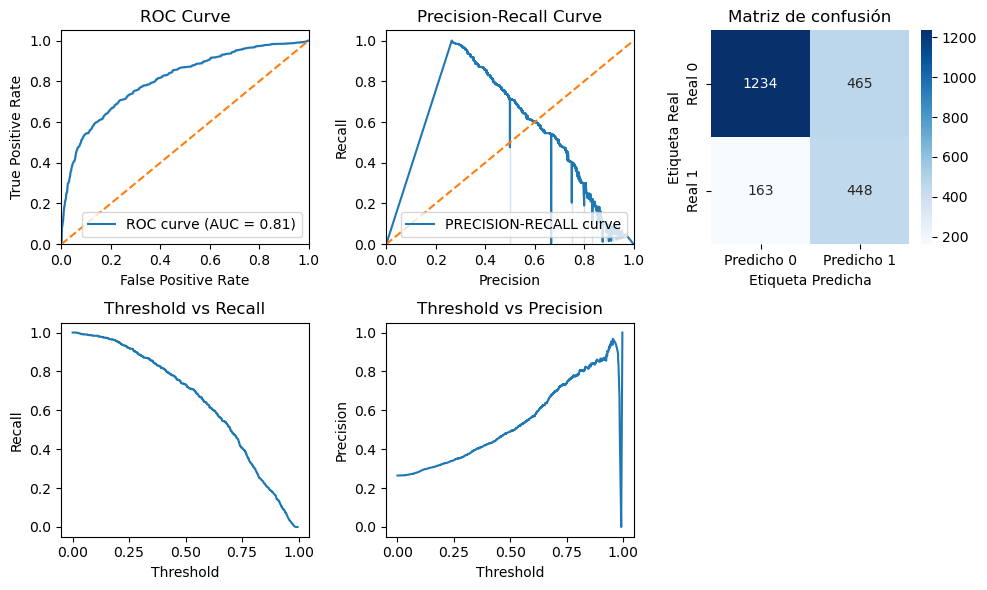

In [6]:
df_log_com = evaluation(Y_test, model_logistic_completo.predict(X_test_scaled), model_logistic_completo.predict_proba(X_test_scaled)[:,1])

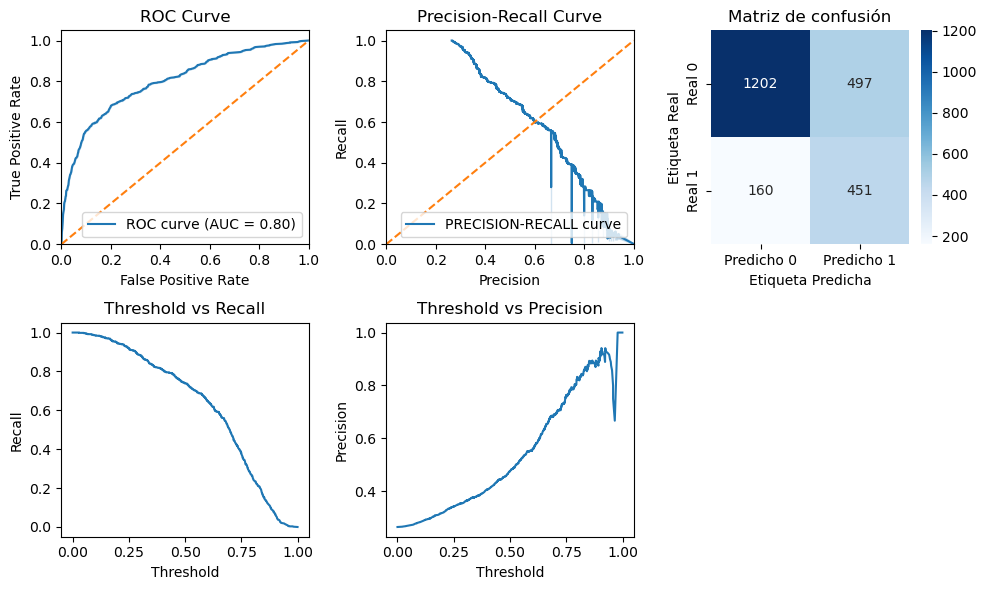

In [7]:
df_log_incom = evaluation(Y_test, model_logistic_incompleto.predict(X_test_reduced_scaled),model_logistic_incompleto.predict_proba(X_test_reduced_scaled)[:,1])

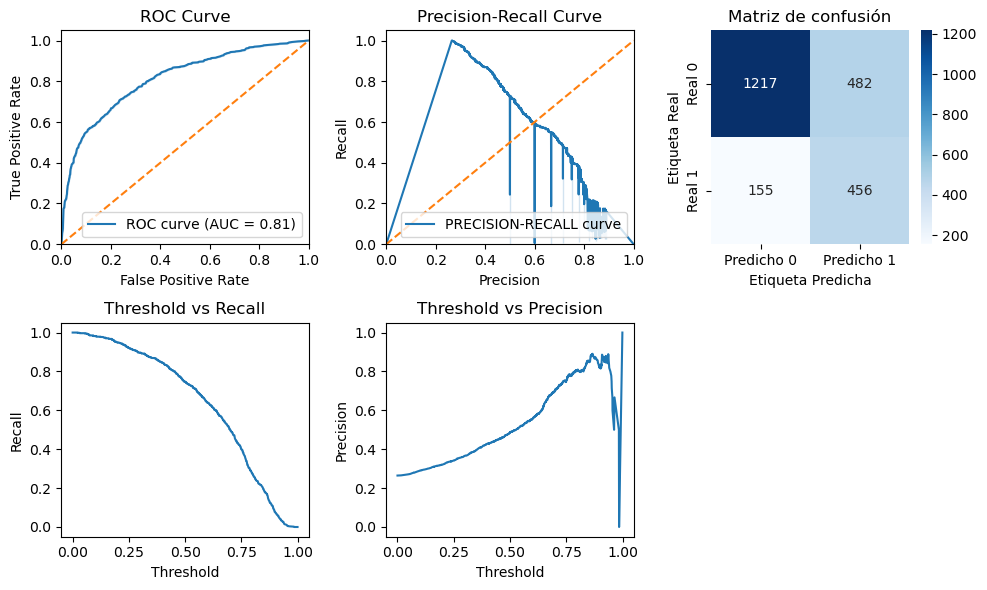

In [8]:
df_log_pca = evaluation(Y_test, model_logistic_pca.predict(X_test_pca),model_logistic_pca.predict_proba(X_test_pca)[:,1])

In [9]:
# Comparativo para Regresión Logística (datasets: completo / incompleto / PCA)
df_logistic_compare = pd.concat([
    df_log_com.rename(columns={'value': 'completo'}),
    df_log_incom.rename(columns={'value': 'incompleto'}),
    df_log_pca.rename(columns={'value': 'pca'})
], axis=1)

print('Logistic comparison:')
df_logistic_compare

Logistic comparison:


,completo,incompleto,pca
precision,0.4907,0.4757,0.4861
recall,0.7332,0.7381,0.7463
accuracy,0.7281,0.7156,0.7242
auc,0.8070,0.8012,0.8115


## ***Decision Trees***

Al igual que en el caso anterior, se entrenaron tres versiones del modelo de **Decision Tree** utilizando las tres representaciones de datos disponibles: dataset completo, dataset reducido por correlación y dataset transformado mediante PCA.

Los resultados obtenidos muestran un desempeño muy similar entre las tres configuraciones evaluadas. No obstante, el modelo entrenado sobre el **dataset completo** obtuvo el mejor valor de **AUC (0.81)**, así como la mayor **precisión (0.63)** entre las tres versiones analizadas. Aunque el modelo entrenado con el dataset reducido presenta un recall ligeramente superior, la diferencia es mínima y se ve compensada por una menor precisión y una menor exactitud global.

Dado que el objetivo en esta etapa es identificar la configuración que ofrezca el mejor equilibrio general entre las métricas de desempeño, el **Decision Tree entrenado sobre el dataset completo** fue seleccionado como la mejor versión de este modelo para continuar con el análisis y el posterior ajuste del umbral de clasificación.

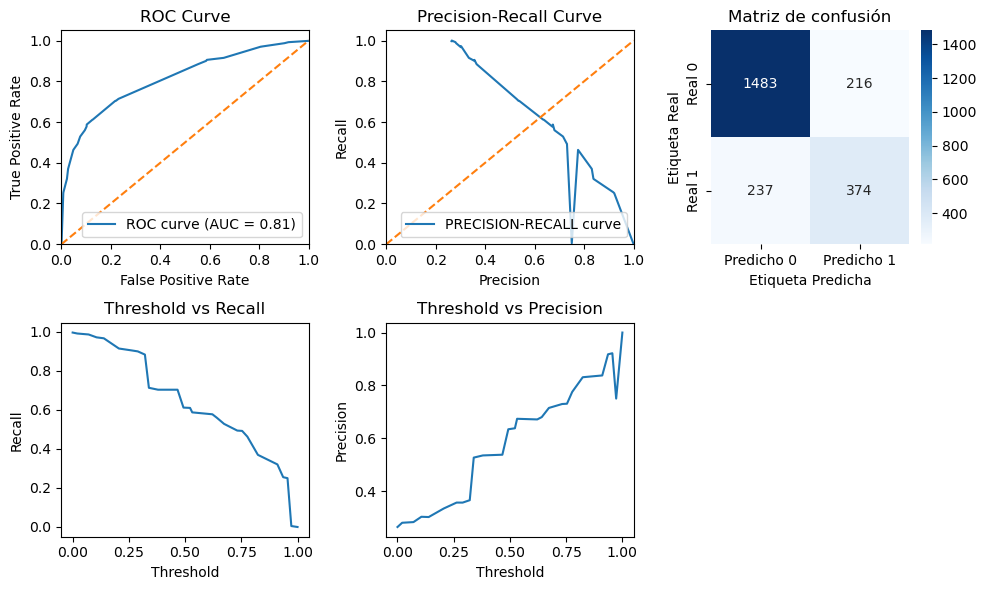

In [10]:
df_dt_com = evaluation(Y_test, model_tree_completo.predict(X_test),model_tree_completo.predict_proba(X_test)[:,1])

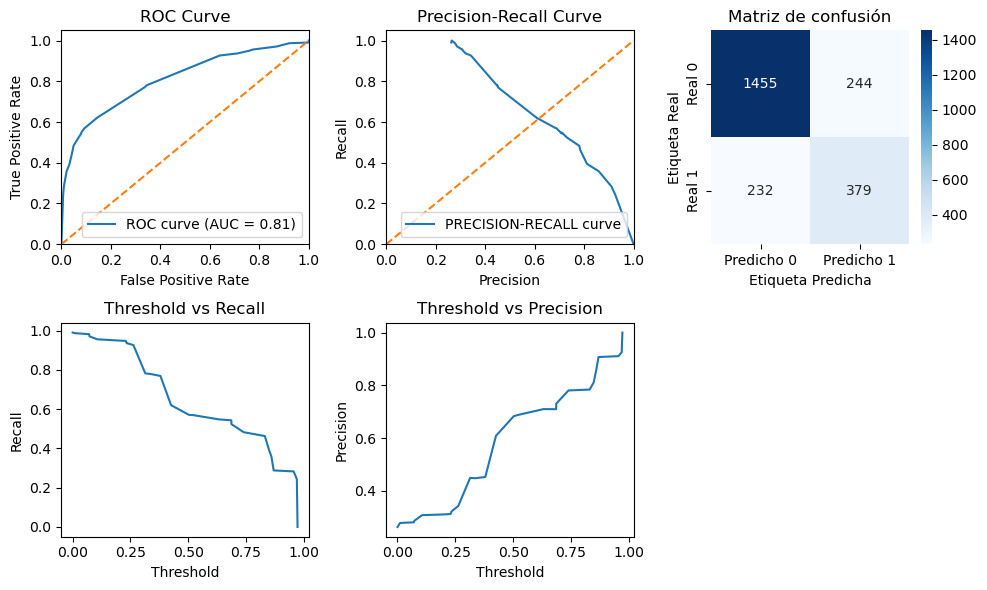

In [11]:
df_dt_incom = evaluation(Y_test, model_tree_incompleto.predict(X_test_reduce),model_tree_incompleto.predict_proba(X_test_reduce)[:,1])

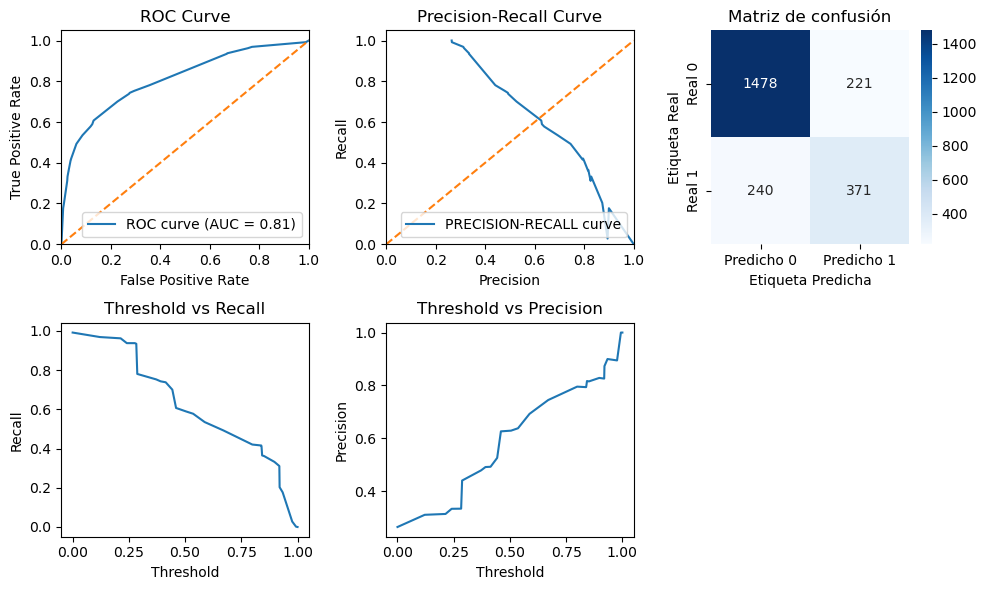

In [12]:
df_dt_pca = evaluation(Y_test, model_tree_pca.predict(X_test_pca),model_tree_pca.predict_proba(X_test_pca)[:,1])

In [13]:
# Comparativo para Decision Tree (datasets: completo / incompleto / PCA)
df_tree_compare = pd.concat([
    df_dt_com.rename(columns={'value': 'completo'}),
    df_dt_incom.rename(columns={'value': 'incompleto'}),
    df_dt_pca.rename(columns={'value': 'pca'})
], axis=1)

print('Decision Tree comparison:')
df_tree_compare

Decision Tree comparison:


,completo,incompleto,pca
precision,0.6339,0.6083,0.6267
recall,0.6121,0.6203,0.6072
accuracy,0.8039,0.7939,0.8004
auc,0.8106,0.8088,0.8083


## ***Random forest***

Se entrenaron tres versiones del modelo de **Random Forest** utilizando las tres representaciones de datos disponibles: dataset completo, dataset reducido por correlación y dataset transformado mediante PCA.

Los resultados muestran que el modelo entrenado sobre el **dataset PCA** obtuvo el mejor desempeño general entre las configuraciones evaluadas. Esta versión alcanzó el mayor valor de **AUC (0.85)**, así como los mejores resultados en **precisión (0.71)**, **recall (0.59)** y **accuracy (0.83)**.

Aunque el modelo entrenado con el dataset completo presenta un desempeño competitivo, el uso de la representación mediante **PCA** permitió obtener una ligera mejora en todas las métricas principales. Esto sugiere que la reducción de dimensionalidad ayudó a capturar de manera más eficiente la información relevante para la predicción en este modelo.

Por esta razón, el **Random Forest entrenado sobre el dataset PCA** fue seleccionado como la mejor versión de este algoritmo para continuar con el análisis y el posterior ajuste del umbral de clasificación.

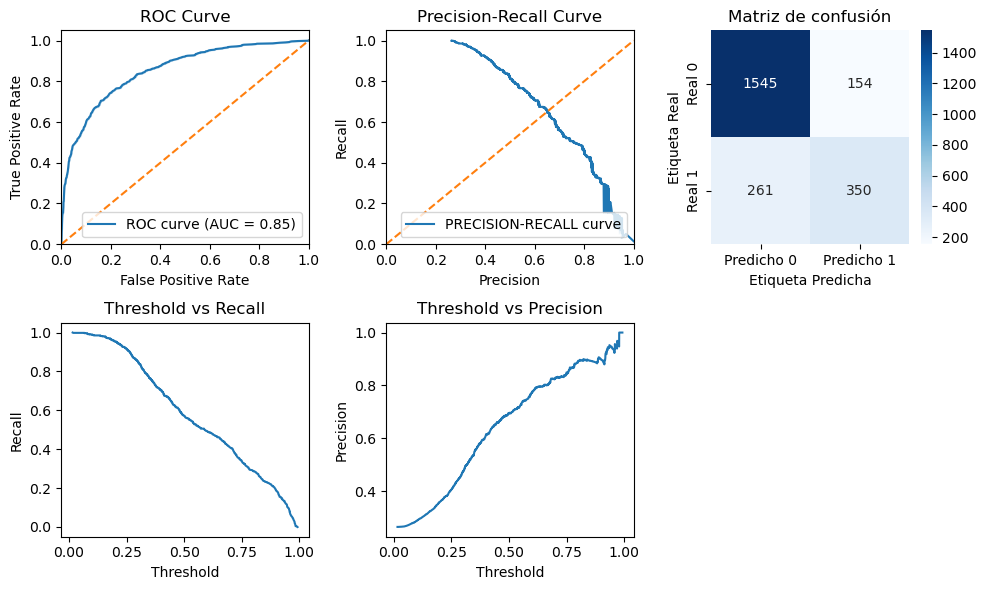

In [14]:
df_Rf_com = evaluation(Y_test, model_rforest_completo.predict(X_test), model_rforest_completo.predict_proba(X_test)[:,1])

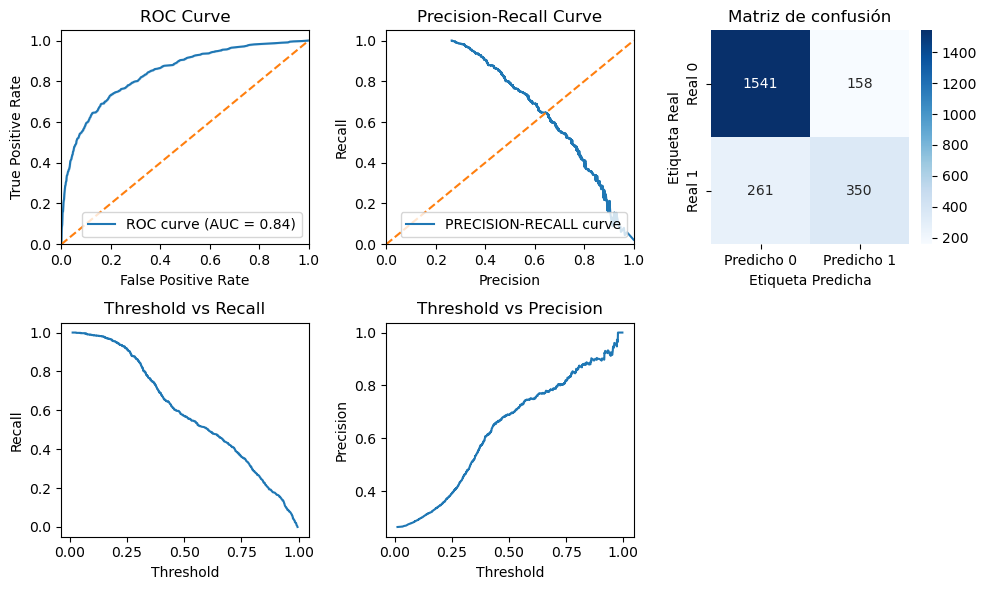

In [15]:
df_Rf_incom = evaluation(Y_test, model_rforest_incompleto.predict(X_test_reduce), model_rforest_incompleto.predict_proba(X_test_reduce)[:,1])

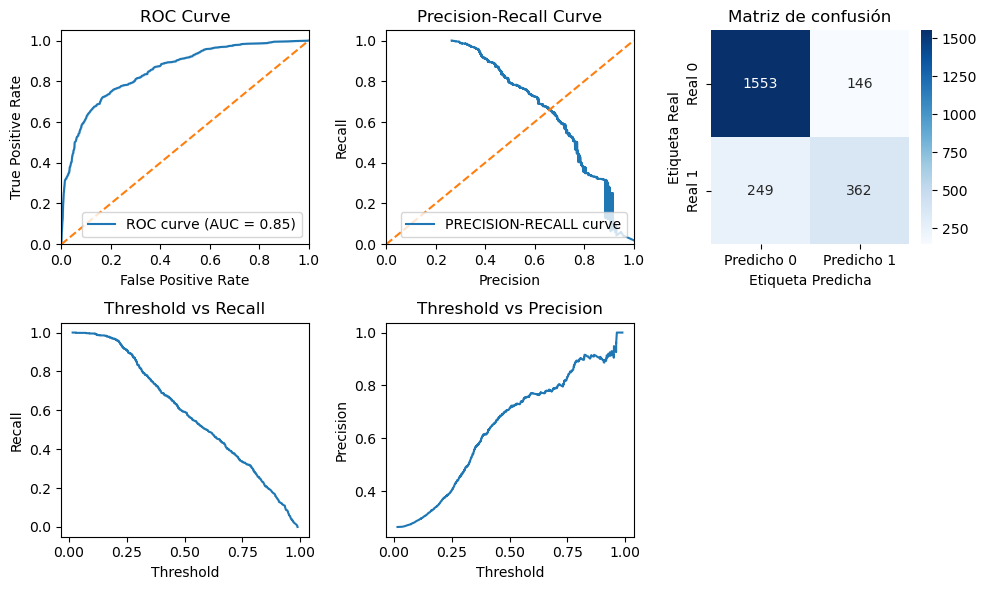

In [16]:
df_Rf_pca = evaluation(Y_test, model_rforest_pca.predict(X_test_pca), model_rforest_pca.predict_proba(X_test_pca)[:,1])


In [17]:
# Comparativo para Random Forest (datasets: completo / incompleto / PCA)
df_rforest_compare = pd.concat([
    df_Rf_com.rename(columns={'value': 'completo'}),
    df_Rf_incom.rename(columns={'value': 'incompleto'}),
    df_Rf_pca.rename(columns={'value': 'pca'})
], axis=1)

print('Random Forest comparison:')
df_rforest_compare

Random Forest comparison:


,completo,incompleto,pca
precision,0.6944,0.6890,0.7126
recall,0.5728,0.5728,0.5925
accuracy,0.8203,0.8186,0.8290
auc,0.8517,0.8422,0.8528


## ***XGBoost***

Siguiendo la misma metodología, se entrenaron tres versiones del modelo de **XGBoost** utilizando el dataset completo, el dataset reducido por correlación y el dataset transformado mediante PCA.

Los resultados muestran que el modelo entrenado con el **dataset completo** obtuvo el mejor desempeño general. Esta configuración alcanzó el mayor valor de **AUC (0.86)**, además de la mayor **precisión (0.77)** y la mejor **exactitud (0.83)** entre las tres versiones evaluadas.

Aunque el modelo entrenado con el dataset reducido presenta un recall ligeramente superior, la diferencia es mínima y se acompaña de una ligera disminución en precisión y AUC. Por otro lado, el modelo basado en PCA muestra un desempeño ligeramente inferior en la mayoría de las métricas.

Dado que el objetivo en esta etapa es seleccionar la configuración que ofrezca el mejor desempeño global del modelo, el **XGBoost entrenado sobre el dataset completo** fue elegido como la mejor versión de este algoritmo para el posterior ajuste del umbral de clasificación.

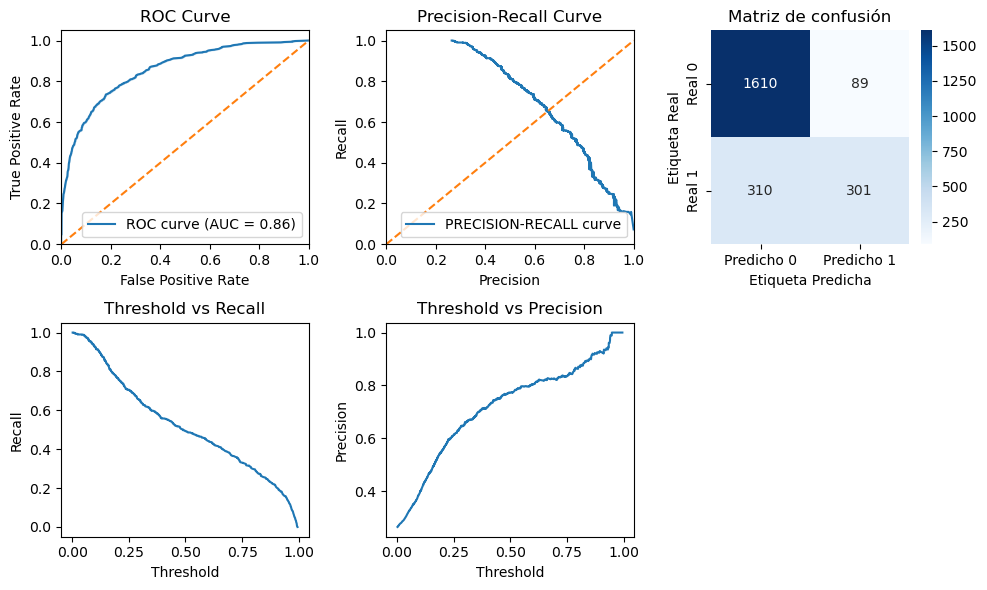

In [18]:
df_xgb_com = evaluation(Y_test, model_XGB_completo.predict(X_test),model_XGB_completo.predict_proba(X_test)[:,1])

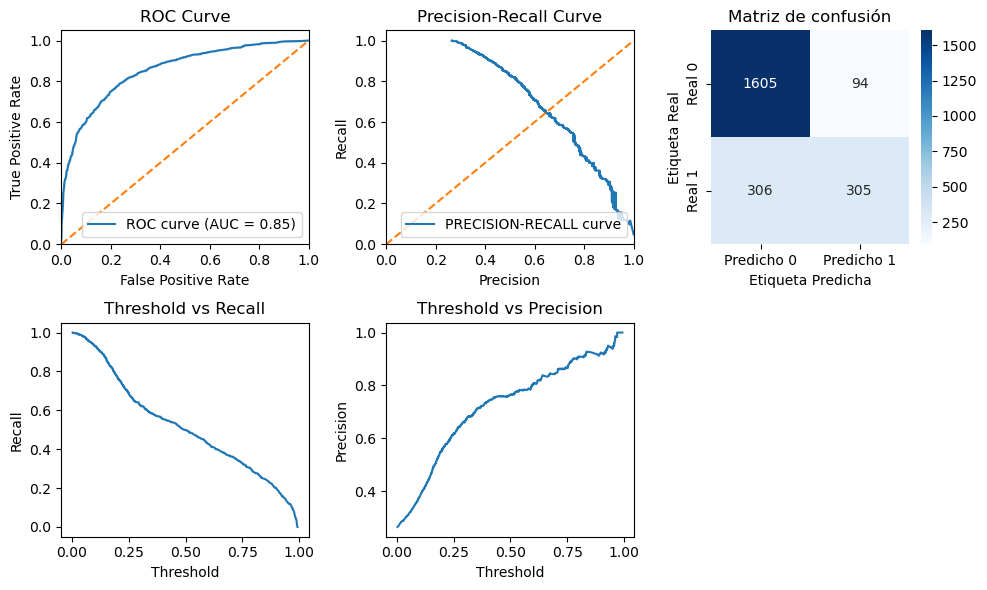

In [19]:
df_xgb_incom = evaluation(Y_test, model_XGB_incompleto.predict(X_test_reduce),model_XGB_incompleto.predict_proba(X_test_reduce)[:,1])

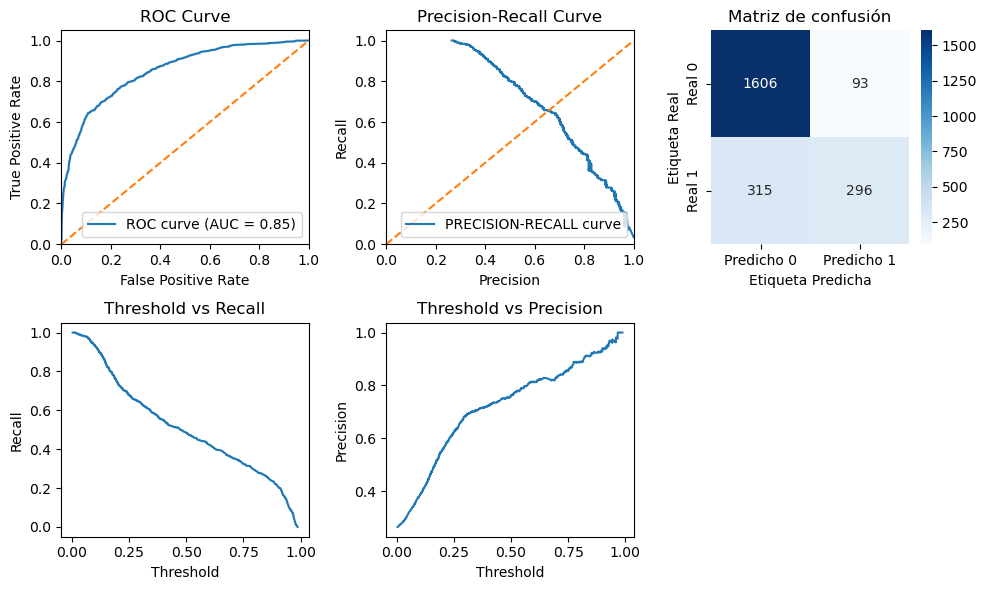

In [20]:
df_xgb_pca = evaluation(Y_test, model_XGB_pca.predict(X_test_pca.to_numpy()),model_XGB_pca.predict_proba(X_test_pca.to_numpy())[:,1])


In [21]:
# Comparativo para XGBoost (datasets: completo / incompleto / PCA)
df_xgb_compare = pd.concat([
    df_xgb_com.rename(columns={'value': 'completo'}),
    df_xgb_incom.rename(columns={'value': 'incompleto'}),
    df_xgb_pca.rename(columns={'value': 'pca'})
], axis=1)

print('XGBoost comparison:')
df_xgb_compare

XGBoost comparison:


,completo,incompleto,pca
precision,0.7718,0.7644,0.7609
recall,0.4926,0.4992,0.4845
accuracy,0.8273,0.8268,0.8234
auc,0.8566,0.8538,0.8514


## Ajuste del Umbral de Decisión

Hasta este punto, los modelos fueron evaluados utilizando el umbral de clasificación por defecto (0.5). Sin embargo, este valor no siempre es el más adecuado cuando el objetivo del problema prioriza una métrica específica.

En este proyecto, el objetivo principal es **minimizar los falsos negativos**, es decir, evitar que un video con alto engagement sea clasificado como uno de bajo engagement. Por esta razón, se decidió **priorizar el recall** sobre la precisión durante la selección final del modelo.

Para lograrlo, se analizó la relación entre **precision, recall y el umbral de decisión** utilizando las curvas de *Precision–Recall* y las gráficas de **threshold vs recall/precision** generadas para cada modelo seleccionado en la etapa anterior. A partir de este análisis, se identificó el umbral mínimo que permitiera alcanzar un **recall ≥ 0.8**, manteniendo al mismo tiempo el mayor nivel posible de precisión.

Este procedimiento se aplicó a los mejores modelos obtenidos en la etapa anterior:

- Logistic Regression (dataset PCA)
- Decision Tree (dataset completo)
- Random Forest (dataset PCA)
- XGBoost (dataset completo)

Para cada uno de estos modelos se recalculó la **matriz de confusión** y las métricas de desempeño utilizando el nuevo umbral seleccionado. Posteriormente, se compararon nuevamente los valores de **precision, recall y accuracy** con el objetivo de identificar el modelo que logra mantener un alto recall sin generar un aumento excesivo en los falsos positivos.

Este proceso permite adaptar el comportamiento del modelo a los objetivos del problema, priorizando la correcta detección de contenidos con alto engagement.

Best models report (adjusted thresholds):


,Logistic,DecisionTree,RandomForest,XGBoost
precision,0.4549,0.3654,0.4959,0.5169
recall,0.8003,0.8838,0.8003,0.8003
accuracy,0.6935,0.5632,0.7320,0.7494
auc,0.8115,0.8106,0.8528,0.8566


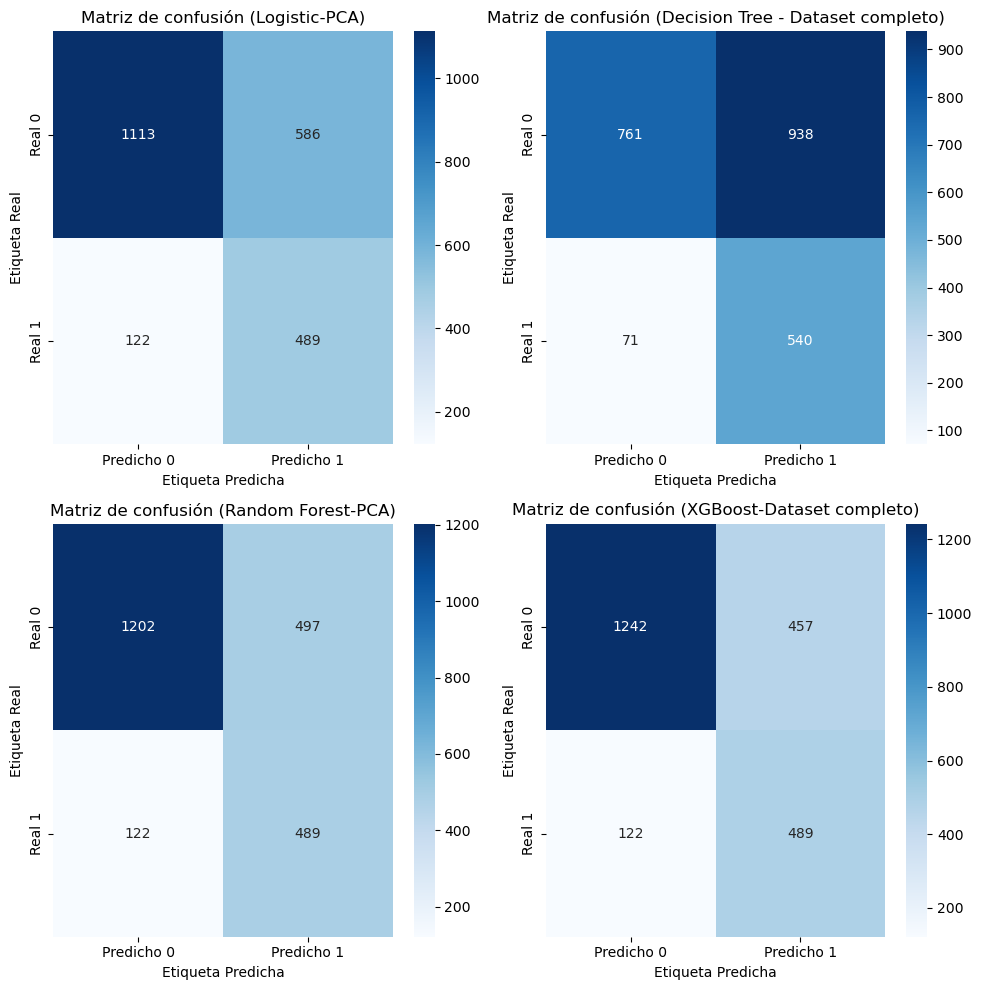

In [22]:
def thresholds_adjust(Y_prob):
    precision, recall, thresholds = precision_recall_curve(Y_test, Y_prob)
    target_recall = 0.80
    valid_idx = np.where(recall[:-1] >= target_recall)[0]
    best_idx = valid_idx[np.argmax(precision[valid_idx])]
    best_threshold = thresholds[best_idx]
    return float(best_threshold)

y_prob_log_pca = model_logistic_pca.predict_proba(X_test_pca)[:,1]
y_prob_dt_com = model_tree_completo.predict_proba(X_test)[:,1]
y_prob_rf_pca = model_rforest_pca.predict_proba(X_test_pca)[:,1]
y_prob_xgb_com = model_XGB_completo.predict_proba(X_test)[:,1]


y_pred_adj_log = (y_prob_log_pca >= thresholds_adjust(y_prob_log_pca)).astype(int)
y_pred_adj_dt = (y_prob_dt_com >= thresholds_adjust(y_prob_dt_com)).astype(int)
y_pred_adj_rf = (y_prob_rf_pca >= thresholds_adjust(y_prob_rf_pca)).astype(int)
y_pred_adj_xgb = (y_prob_xgb_com >= thresholds_adjust(y_prob_xgb_com)).astype(int)

fig, axs = plt.subplots(2,2,figsize= (10,10))
sns.heatmap(confusion_matrix(Y_test, y_pred_adj_log), annot=True, cmap='Blues', fmt='d',
                xticklabels=['Predicho 0', 'Predicho 1'],
                yticklabels=['Real 0', 'Real 1'], ax=axs[0,0])
axs[0,0].set_xlabel('Etiqueta Predicha')
axs[0,0].set_ylabel('Etiqueta Real')
axs[0,0].set_title('Matriz de confusión (Logistic-PCA)')

sns.heatmap(confusion_matrix(Y_test, y_pred_adj_dt), annot=True, cmap='Blues', fmt='d',
                xticklabels=['Predicho 0', 'Predicho 1'],
                yticklabels=['Real 0', 'Real 1'], ax=axs[0,1])
axs[0,1].set_xlabel('Etiqueta Predicha')
axs[0,1].set_ylabel('Etiqueta Real')
axs[0,1].set_title('Matriz de confusión (Decision Tree - Dataset completo)')

sns.heatmap(confusion_matrix(Y_test, y_pred_adj_rf), annot=True, cmap='Blues', fmt='d',
                xticklabels=['Predicho 0', 'Predicho 1'],
                yticklabels=['Real 0', 'Real 1'], ax=axs[1,0])
axs[1,0].set_xlabel('Etiqueta Predicha')
axs[1,0].set_ylabel('Etiqueta Real')
axs[1,0].set_title('Matriz de confusión (Random Forest-PCA)')

sns.heatmap(confusion_matrix(Y_test, y_pred_adj_xgb), annot=True, cmap='Blues', fmt='d',
                xticklabels=['Predicho 0', 'Predicho 1'],
                yticklabels=['Real 0', 'Real 1'], ax=axs[1,1])
axs[1,1].set_xlabel('Etiqueta Predicha')
axs[1,1].set_ylabel('Etiqueta Real')
axs[1,1].set_title('Matriz de confusión (XGBoost-Dataset completo)')
plt.tight_layout()

cr_adj_log = classification_report(Y_test, y_pred_adj_log, output_dict=True)
cr_adj_dt = classification_report(Y_test, y_pred_adj_dt, output_dict=True)
cr_adj_rf = classification_report(Y_test, y_pred_adj_rf, output_dict=True)
cr_adj_xgb = classification_report(Y_test, y_pred_adj_xgb, output_dict=True)

best_models_report = pd.DataFrame(
    {
        'Logistic': [
            cr_adj_log['1']['precision'],
            cr_adj_log['1']['recall'],
            accuracy_score(Y_test, y_pred_adj_log),
            roc_auc_score(Y_test, y_prob_log_pca),
        ],
        'DecisionTree': [
            cr_adj_dt['1']['precision'],
            cr_adj_dt['1']['recall'],
            accuracy_score(Y_test, y_pred_adj_dt),
            roc_auc_score(Y_test, y_prob_dt_com),
        ],
        'RandomForest': [
            cr_adj_rf['1']['precision'],
            cr_adj_rf['1']['recall'],
            accuracy_score(Y_test, y_pred_adj_rf),
            roc_auc_score(Y_test, y_prob_rf_pca),
        ],
        'XGBoost': [
            cr_adj_xgb['1']['precision'],
            cr_adj_xgb['1']['recall'],
            accuracy_score(Y_test, y_pred_adj_xgb),
            roc_auc_score(Y_test, y_prob_xgb_com),
        ],
    },
    index=['precision', 'recall', 'accuracy', 'auc'],
).round(4)

print('Best models report (adjusted thresholds):')
best_models_report


## Selección del Mejor Modelo

Tras el ajuste del umbral de decisión, se compararon los mejores modelos obtenidos para cada método con el objetivo de identificar cuál logra **mantener un recall alto sin incrementar excesivamente los falsos positivos**. En todos los casos se seleccionó un umbral que garantizara un **recall mínimo de 0.8**, priorizando así la correcta identificación de videos con alto engagement.

Los resultados obtenidos muestran que todos los modelos evaluados lograron alcanzar el objetivo de recall establecido, aunque con diferencias importantes en precisión y exactitud global.

El **Decision Tree** alcanzó el mayor recall (0.88), lo que indica una alta capacidad para detectar casos positivos. Sin embargo, este desempeño se logra a costa de un aumento considerable en los falsos positivos, lo que se refleja en una precisión significativamente menor (0.36) y una exactitud global de apenas 0.56. Esto sugiere que el modelo tiende a clasificar demasiados casos como positivos.

Por su parte, el modelo de **Logistic Regression (PCA)** logró mantener el recall objetivo (0.80), pero con una precisión relativamente baja (0.45), lo que implica un número considerable de falsos positivos.

El modelo de **Random Forest (PCA)** muestra una mejora clara respecto a los anteriores, alcanzando un recall de 0.80 con una precisión cercana a 0.50 y una exactitud de 0.73. Esto indica un mejor equilibrio entre la detección de casos positivos y la reducción de falsas alarmas.

Finalmente, el modelo de **XGBoost entrenado con el dataset completo** presenta el mejor desempeño general entre los modelos evaluados. Este modelo mantiene el recall objetivo (0.80) mientras logra la **mayor precisión (0.52)** y la **mayor exactitud (0.75)** del conjunto. Además, su matriz de confusión muestra el menor número de falsos positivos entre los modelos que alcanzan el recall deseado.

En consecuencia, el **modelo XGBoost entrenado con el dataset completo y utilizando el umbral ajustado** fue seleccionado como el **modelo final del proyecto**, ya que ofrece el mejor equilibrio entre la detección de casos de alto engagement y la reducción de clasificaciones incorrectas.